# Does buying the dip on a "stretched" stock actually pay off? 🪀
### The Disparity Index — a Korean trading-room staple that turns out to be half right, half backwards, and mostly captured drift

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![More_than_reversal%3F: Busted](https://img.shields.io/badge/More_than_reversal%3F-Busted-8b949e?style=flat-square)

Look at any stock chart and draw its moving average. Sometimes the price is way above that line, sometimes way below it — like a rubber band stretched away from its resting point. The **Disparity Index** puts a number on that stretch (100 = sitting right on the average, 105 = 5% above, 95 = 5% below) and makes a very old promise: *when the band is stretched, it snaps back.*

That's the claim we test — on SPY plus five liquid names (QQQ, IWM, AAPL, TSLA, NVDA), 2003 to today. Most rubber-band stories die on contact with a control group. This one dies in a particularly instructive way.

> 📓 **Plain-language layer.** Want the *t*-stats, the drift-control math and the parameter grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** DI(10) = 100 x close / its own 10-day average; oversold < 95, overbought > 105 — the textbook short-horizon defaults, tested exactly as stated. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from disparity_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real()
else:
    BARS = None
print("real cache present:", HAVE_REAL, "| universe:", ", ".join(data.UNIVERSE),
      "| tape rows (SPY):", (0 if BARS is None else len(BARS["SPY"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2003-01-02', 'end': '2026-06-30', 'window': 10, 'oversold': 95.0, 'overbought': 105.0, 'hold': 5, 'n_low': 1825, 'n_mid': 29406, 'n_high': 2338, 'mean_low_bps': 111.6, 'mean_mid_bps': 38.16, 'mean_high_bps': 99.64, 'welch_low': 3.84, 'nw_low': 2.5, 'welch_high': 4.3, 'nw_high': 2.68, 'timer_n': 4163, 'timer_win5': 48.8, 'timer_mean5': -17.03, 'timer_t5': -0.94, 'coin_win5': 49.1, 'coin_mean5': 0.87, 'coin_t5': 0.07, 'timer_win10': 48.3, 'timer_mean10': -27.03, 'timer_t10': -1.49, 'coin_win10': 48.5, 'coin_mean10': -9.13, 'coin_t10': -0.75, 'delta5': -17.9, 'delta5_t': -1.09, 'dl_n': 1825, 'dl_mean': 101.6, 'dl_t': 3.49, 'dl_rand': 67.05, 'dl_rand_t': 4.51, 'dl_delta': 34.55, 'dl_delta_t': 1.42, 'dh_n': 2338, 'dh_mean': -109.64, 'dh_t': -4.87, 'dh_rand': -91.32, 'dh_rand_t': -6.73, 'dh_delta': -18.31, 'dh_delta_t': -0.94, 'corr_n': 33515, 'corr': 0.8366, 'grid': {5: {(97, 103): (3.65, 1.74), (95, 105): (3.14, 2.12), (93, 107): (3.03, 2.73)}, 10: {(97, 103): (3.11, 3.63), (95, 105): (3.84, 4.3), (93, 107): (3.53, 4.54)}, 20: {(97, 103): (3.91, 8.09), (95, 105): (3.5, 7.24), (93, 107): (3.95, 6.99)}, 25: {(97, 103): (4.6, 8.85), (95, 105): (3.78, 7.93), (93, 107): (3.45, 7.01)}}, 'syn_null_welch_lo': (-0.16, 1.55, 5), 'syn_null_welch_hi': (0.09, 1.27, 2), 'syn_null_nw_lo': (-0.08, 1.25, 2), 'syn_null_nw_hi': (0.06, 0.99, 1), 'syn_planted_welch': (3.88, -2.47), 'syn_planted_nw': (3.33, -2.09), 'fp_spy': 'c6509bba7177', 'fp_qqq': '824e9d9be08f', 'fp_iwm': '1a82f99e4745', 'fp_aapl': 'db335bf7a084', 'fp_tsla': '1d273fa4b475', 'fp_nvda': 'e3f7f5f85931'}


real cache present: True | universe: SPY, QQQ, IWM, AAPL, TSLA, NVDA | tape rows (SPY): 5910


## The answer first

| Question | Answer |
|---|---|
| Do stretched-down days really bounce more than average? | **Yes, on the raw numbers.** +112 bps over the next 5 days vs +38 bps on a normal day (*t* = 3.84). |
| Do stretched-*up* days sell off, like the folklore says? | **No — the opposite.** They keep going *up* by even more (+100 bps, *t* = 4.30). Half the rule is simply backwards on this tape. |
| Is the "buy the dip" half really a *signal*, or just a good stock having a good two decades? | **Mostly the latter.** Buying an *arbitrary* random day of the same stocks already earns +67 bps — buying specifically the dip only adds **+35 bps more**, and that extra bit is statistically unconvincing (*t* = 1.42). |
| Can you trade the literal two-sided rule (buy dips, short rips)? | **No — it loses money.** −17 bps per trade after costs, no better than a coin flip on the same days. |

> The rubber band doesn't snap back. The stocks that were already running kept running, and the ones that dipped were mostly riding the same tide as every other day.

## 1 · The claim

> *"Price always reverts to its moving average. When the Disparity Index (close as a percent of its own N-day average) drifts too far from 100, that's the market overextending itself — fade the stretch."*

It's a fixture of Korean and Japanese retail technical-analysis education, alongside cousins like the Psychological Line ([sibling study 679](../../679-psychological-line/)). Unlike some folklore, it at least has an intuitive mechanism: a price a long way from its own recent average has, definitionally, moved a lot lately — and "what goes up a lot, comes down a bit" is a real phenomenon in *some* markets, *some* of the time.

## 2 · So what?

If real, this is about as simple as a trading rule gets: one moving average, one ratio, two thresholds — no options, no leverage, no news to read. It's the kind of rule a retail trading room can actually run by hand. So the stakes are practical: does the rubber band actually snap back often enough, hard enough, and *both directions* to pay for itself after costs — or is it quietly riding something else entirely (like the fact that a few of these stocks have been extraordinary investments for two decades)?

## 3 · How would we even know?

- **The comparison.** Bucket every trading day by its DI(10) reading — oversold (< 95), overbought (> 105), neutral — and compare the *next 5 trading days'* return across buckets.
- **The literal trade.** Buy the day DI first dips below 95, short the day it first pops above 105, hold 5 days, pay round-trip costs, compare to a coin flip on the same entry days.
- **The honest control.** These six tickers have had a very good two decades. So the real question isn't "does DI beat a coin flip" — it's **"does buying the dip beat simply buying an arbitrary day of the same stock?"** That's the control that actually decides it.

## 4 · The teardown — let's actually look

**First, the headline split.** Forward 5-day return by DI bucket.

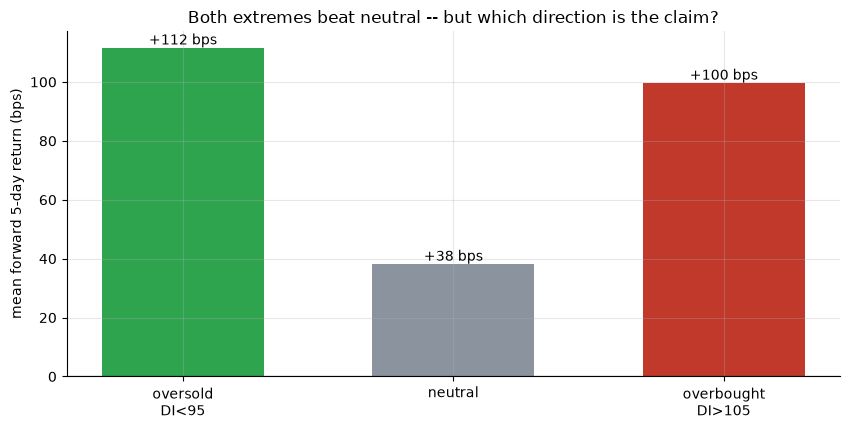

oversold +111.60 bps | neutral +38.16 bps | overbought +99.64 bps


In [2]:
if HAVE_REAL:
    c = st.pooled_conditional(BARS, window=R['window'], oversold=R['oversold'],
                              overbought=R['overbought'], h=R['hold'])
    lo, mid, hi = c['mean_low_bps'], c['mean_mid_bps'], c['mean_high_bps']
else:
    lo, mid, hi = R['mean_low_bps'], R['mean_mid_bps'], R['mean_high_bps']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labels = ['oversold\nDI<95', 'neutral', 'overbought\nDI>105']
vals = [lo, mid, hi]
cols = [GREEN, GREY, RED]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward 5-day return (bps)')
ax.set_title('Both extremes beat neutral -- but which direction is the claim?')
plt.tight_layout(); plt.show()
print(f'oversold {lo:+.2f} bps | neutral {mid:+.2f} bps | overbought {hi:+.2f} bps')

Both extremes beat the neutral day — oversold **+112 bps** (*t* = 3.84), overbought **+100 bps** (*t* = 4.30). Read that last number again: the claim says overbought should **underperform**. It doesn't — it's the *strongest* bucket on the chart. That's a momentum signature, not a rubber band.

**Second, the literal trade.** Buy the dip, short the rip, exactly as the rule says — does it pay?

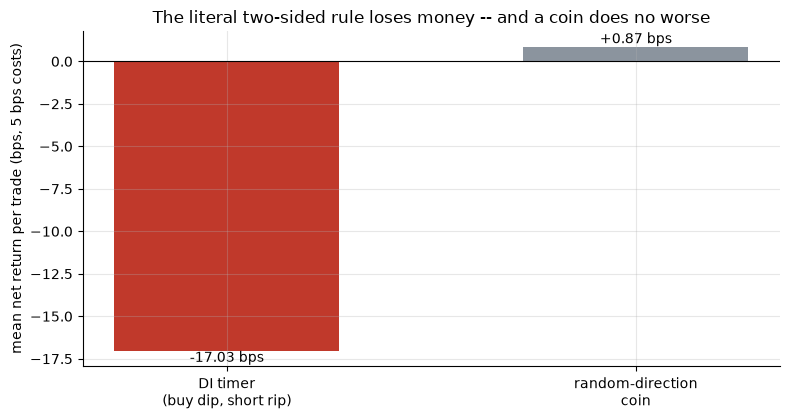

DI timer -17.03 bps/trade  |  coin +0.87 bps/trade


In [3]:
if HAVE_REAL:
    strat, rand = st.pooled_trade_ledger(BARS, window=R['window'], oversold=R['oversold'],
                                         overbought=R['overbought'], hold_days=R['hold'],
                                         cost_bps=5.0, seed=680)
    ss, rs = st.summarize(strat, 'ret_net', lags=R['hold']), st.summarize(rand, 'ret_net', lags=R['hold'])
    sm, cm = ss['mean_bps'], rs['mean_bps']
else:
    sm, cm = R['timer_mean5'], R['coin_mean5']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['DI timer\n(buy dip, short rip)', 'random-direction\ncoin'], [sm, cm],
       color=[RED, GREY], width=.55)
for i,v in enumerate([sm, cm]): ax.annotate(f'{v:+.2f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean net return per trade (bps, 5 bps costs)')
ax.set_title('The literal two-sided rule loses money -- and a coin does no worse')
plt.tight_layout(); plt.show()
print(f'DI timer {sm:+.2f} bps/trade  |  coin {cm:+.2f} bps/trade')

Net of costs, the DI timer loses **-17.0 bps per trade** (*t* = -0.94) — and a coin flip on the *same* entry days does *better* (+0.9 bps). The short-overbought leg is fighting real momentum, and it shows.

**Third — the question that actually settles it.** These six stocks have had an extraordinary run since 2003 (NVDA and TSLA especially). So: does buying specifically the *dip* beat simply buying *any* day of the same stock?

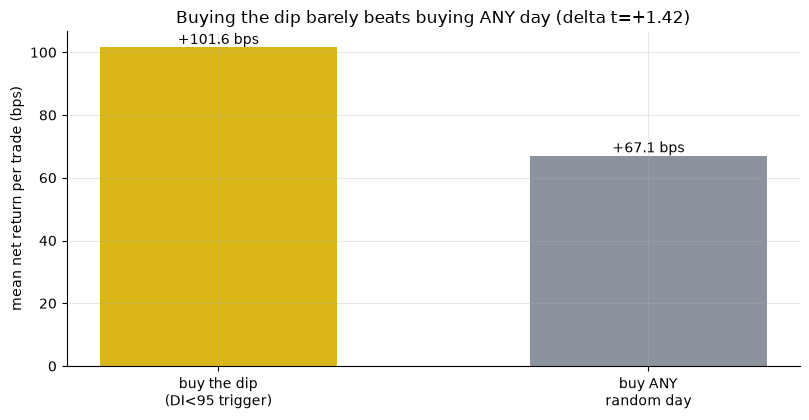

buy-the-dip +101.60 bps  vs  random-day +67.05 bps  delta +34.55 bps (t=+1.42)


In [4]:
if HAVE_REAL:
    db = st.random_day_baseline(BARS, window=R['window'], oversold=R['oversold'],
                                overbought=R['overbought'], hold_days=R['hold'],
                                cost_bps=5.0, seed=680)
    dl, dl_r = db['low']['mean_bps'], db['low']['rand_mean_bps']
else:
    dl, dl_r = R['dl_mean'], R['dl_rand']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['buy the dip\n(DI<95 trigger)', 'buy ANY\nrandom day'], [dl, dl_r],
       color=[AMBER, GREY], width=.55)
for i,v in enumerate([dl, dl_r]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
ax.set_ylabel('mean net return per trade (bps)')
ax.set_title(f'Buying the dip barely beats buying ANY day (delta t={R["dl_delta_t"]:+.2f})')
plt.tight_layout(); plt.show()
print(f'buy-the-dip {dl:+.2f} bps  vs  random-day {dl_r:+.2f} bps  '
      f'delta {R["dl_delta"]:+.2f} bps (t={R["dl_delta_t"]:+.2f})')

There it is. Buying an *arbitrary* day of the same six stocks already earns **+67 bps** over 5 days — because these are, on average, stocks that went up a lot. Timing the dip with DI only adds **+35 bps** on top, and that sliver isn't statistically convincing (*t* = 1.42, below the desk's bar of 2). The "signal" in the first chart was mostly the tide, not the timing.

**One more nail.** Is the Disparity Index even a *distinct* idea?

In [5]:
if HAVE_REAL:
    dc = st.di_return_correlation(BARS, window=R['window'])
    corr = dc['corr']
else:
    corr = R['corr']
print(f'correlation between DI and the plain trailing {R["window"]}-day return: r = {corr:.3f}')
print('a value this close to 1 means DI is basically a relabeled version of the')
print('same trailing-return signal tested (and found weak/microstructural) in')
print('sibling study 329-one-month-reversal.')

correlation between DI and the plain trailing 10-day return: r = 0.837
a value this close to 1 means DI is basically a relabeled version of the
same trailing-return signal tested (and found weak/microstructural) in
sibling study 329-one-month-reversal.


**r = 0.84.** The Disparity Index and the plain trailing return are almost the same number wearing different clothes. That's not a coincidence — distance-from-a-moving-average is mathematically close to accumulated return over the window. It's not a new discovery about market psychology; it's short-term reversal with a Korean name.

## 5 · The verdict

- **Signal — Weak.** Real on the raw split (both legs *t* > 3.8) but the overbought leg has the wrong sign, and the surviving oversold leg loses its edge against a same-stock random-day control (*t* = 1.42).
- **Tradability — Mirage.** The literal rule loses money net of costs and doesn't beat a coin flip.
- **"More than plain short-term reversal?" — Busted.** r = 0.84 with the trailing return; it's the same signal, already characterized as microstructure by a sibling study.

## 6 · Going further 🚪

- **The general lesson:** any "distance from an average" indicator, on a universe that has genuinely trended, will look like it's picking up reversion when it's actually just picking up drift. Always ask for the random-*day* control, not just the random-*direction* coin.
- **Where this indicator might still earn its keep:** a genuinely mean-reverting, non-trending universe (a sideways commodity, a pairs-trade spread) — the opposite of six of the best-performing large caps of the last two decades.
- **Sibling studies:** [329-one-month-reversal](../../329-one-month-reversal/) (the ancestor DI turns out to be), [104-bollinger-reversion](../../104-bollinger-reversion/) (the Western band cousin, same drift trap), [679-psychological-line](../../679-psychological-line/) (the matched-protocol sibling on the same universe).

*Think the Disparity Index earns its keep on a genuinely range-bound tape? Show a net, certifiable edge on a sideways commodity or index versus its own random-day control — then we'll talk.*